In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
!git clone https://github.com/niaz1971/From-Industry-4_0-to_5_0_Advanced_ML_Industrial-Anomaly-Detection-and-Fault-Classification.git

Cloning into 'From-Industry-4_0-to_5_0_Advanced_ML_Industrial-Anomaly-Detection-and-Fault-Classification'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 289.52 KiB | 1.47 MiB/s, done.


In [3]:
!ls

From-Industry-4_0-to_5_0_Advanced_ML_Industrial-Anomaly-Detection-and-Fault-Classification
sample_data


In [4]:
path = 'From-Industry-4_0-to_5_0_Advanced_ML_Industrial-Anomaly-Detection-and-Fault-Classification/equipment_anomaly_data.csv'

In [5]:
df_raw = pd.read_csv(path)
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


In [6]:
df = df_raw.copy()

In [7]:
df['faulty'] = df['faulty'].astype(bool)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   bool   
dtypes: bool(1), float64(4), object(2)
memory usage: 367.2+ KB


In [8]:
equips = [equip for equip in df['equipment'].unique()]
print(f"Equipments: {equips}")

Equipments: ['Turbine', 'Compressor', 'Pump']


equipment
Compressor    2573
Turbine       2565
Pump          2534
Name: count, dtype: int64


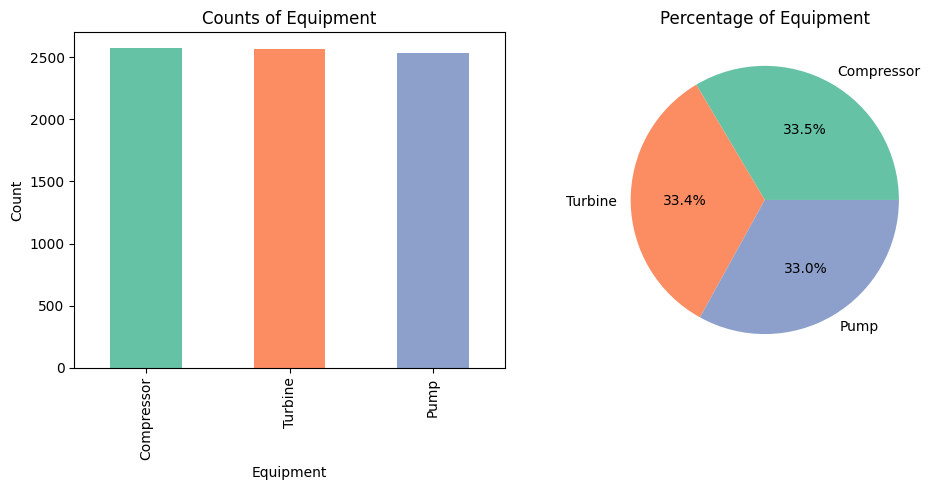

In [9]:
import matplotlib.pyplot as plt

df_equip_counts = df['equipment'].value_counts()
print(df_equip_counts)

# Convert tuple slice to a list so Pandas recognizes it as multiple colors
colors = list(plt.cm.Set2.colors[:len(df_equip_counts)])

plt.figure(figsize=(10, 5))

# Subplot 1: Bar Chart
plt.subplot(1, 2, 1)
df_equip_counts.plot(kind='bar', color=colors)
plt.xlabel('Equipment')
plt.ylabel('Count')
plt.title('Counts of Equipment')

# Subplot 2: Pie Chart
plt.subplot(1, 2, 2)
df_equip_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors)
plt.ylabel('')
plt.title('Percentage of Equipment')

plt.tight_layout()
plt.show()

Locations: ['Atlanta', 'Chicago', 'San Francisco', 'New York', 'Houston']
location
Atlanta          1564
Chicago          1553
Houston          1548
New York         1526
San Francisco    1481
Name: count, dtype: int64


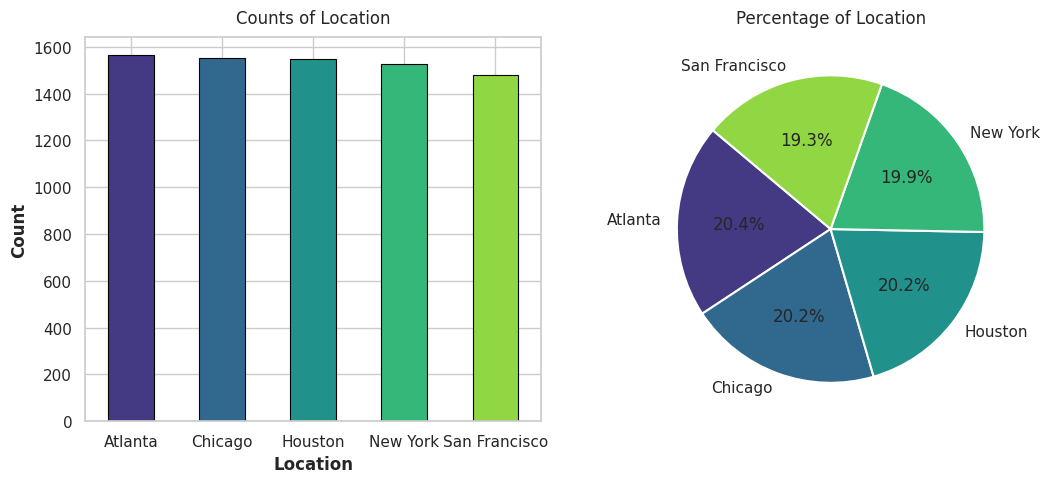

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean seaborn styling globally
sns.set_theme(style="whitegrid")

# Extract location data
locations = list(df['location'].unique())
print(f"Locations: {locations}")

df_location_counts = df['location'].value_counts()
print(df_location_counts)

# Generate a vibrant, cohesive palette guaranteed to match category length
colors = sns.color_palette("viridis", len(df_location_counts))

plt.figure(figsize=(11, 5))

# Subplot 1: Bar Chart
plt.subplot(1, 2, 1)
df_location_counts.plot(
    kind='bar', color=colors, edgecolor='black', linewidth=0.8
)
plt.xlabel('Location', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Counts of Location', fontsize=12, pad=10)
plt.xticks(rotation=0)

# Subplot 2: Pie Chart
plt.subplot(1, 2, 2)
df_location_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
plt.ylabel('')
plt.title('Percentage of Location', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

equipment      Compressor  Pump  Turbine
location                                
Atlanta               520   504      540
Chicago               535   517      501
Houston               505   516      527
New York              520   508      498
San Francisco         493   489      499


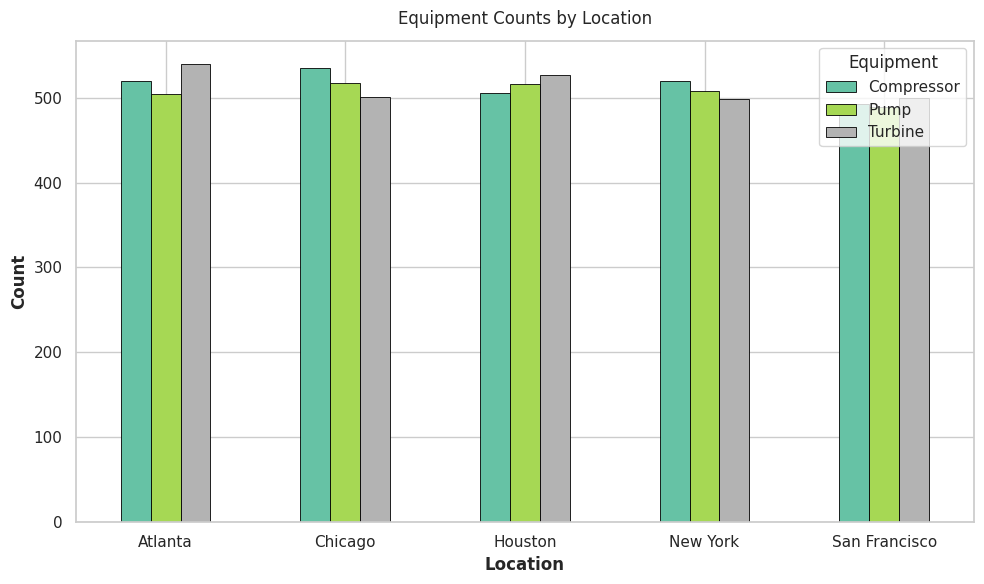

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic styling
sns.set_theme(style="whitegrid")

# Create pivot table
df_location_equip_counts = df.pivot_table(
    index='location', columns='equipment', aggfunc='size', fill_value=0
)
print(df_location_equip_counts)

# Plot using Pandas with a cohesive qualitative colormap ('Set2', 'Spectral', or 'viridis')
ax = df_location_equip_counts.plot(
    kind='bar',
    colormap='Set2',
    edgecolor='black',
    linewidth=0.6,
    figsize=(10, 6),
)

plt.xlabel('Location', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Equipment Counts by Location', fontsize=12, pad=12)
plt.xticks(rotation=0)
plt.legend(title='Equipment', frameon=True)
plt.tight_layout()

plt.show()

In [12]:
print(df['temperature'].describe())

count    7672.000000
mean       70.922478
std        16.200059
min        10.269385
25%        62.777057
50%        70.156900
75%        77.568387
max       149.690420
Name: temperature, dtype: float64


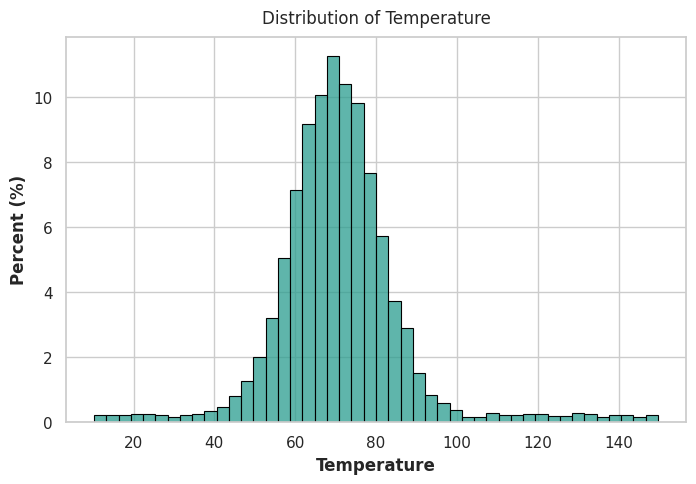

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="temperature",
    stat="percent",
    binwidth=3,
    color="#2A9D8F",  # Teal accent
    edgecolor="black",
    linewidth=0.8,
)

plt.xlabel("Temperature", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Distribution of Temperature", fontsize=12, pad=10)

plt.show()

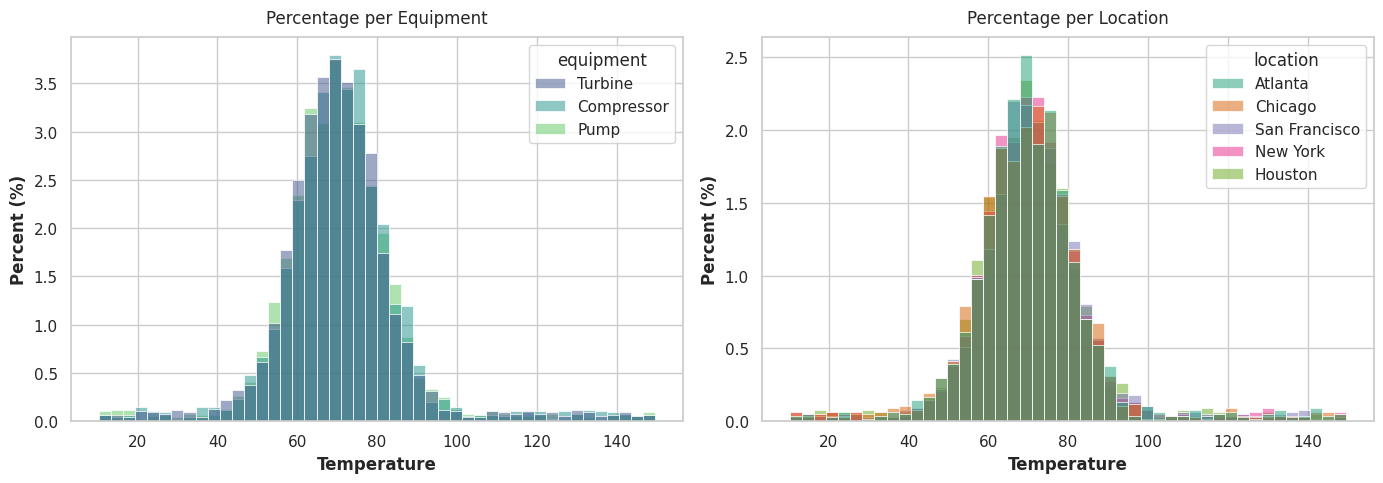

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic styling
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Subplot 1: Equipment (Viridis Palette)
plt.subplot(1, 2, 1)
sns.histplot(
    data=df,
    x="temperature",
    hue="equipment",
    stat="percent",
    binwidth=3,
    palette="viridis",
    multiple="layer",
    edgecolor="white",
    linewidth=0.5,
)
plt.xlabel("Temperature", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Equipment", fontsize=12, pad=10)

# Subplot 2: Location (Dark2 Qualitative Palette)
plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x="temperature",
    hue="location",
    stat="percent",
    binwidth=3,
    palette="Dark2",
    multiple="layer",
    edgecolor="white",
    linewidth=0.5,
)
plt.xlabel("Temperature", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Location", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

In [15]:
print(df['pressure'].describe())

count    7672.000000
mean       35.738048
std        10.381593
min         3.620798
25%        29.485682
50%        35.227544
75%        41.159913
max        79.887734
Name: pressure, dtype: float64


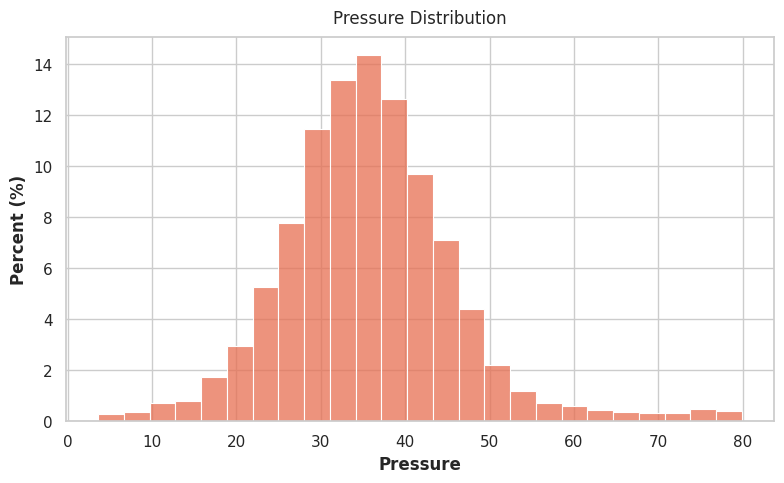

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Simple, clean histogram with a custom coral hex color
sns.histplot(
    data=df,
    x="pressure",
    stat="percent",
    binwidth=3,
    color="#E76F51",  # Warm coral/terracotta color
    edgecolor="white",
    linewidth=0.8,
)

plt.xlabel("Pressure", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Pressure Distribution", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

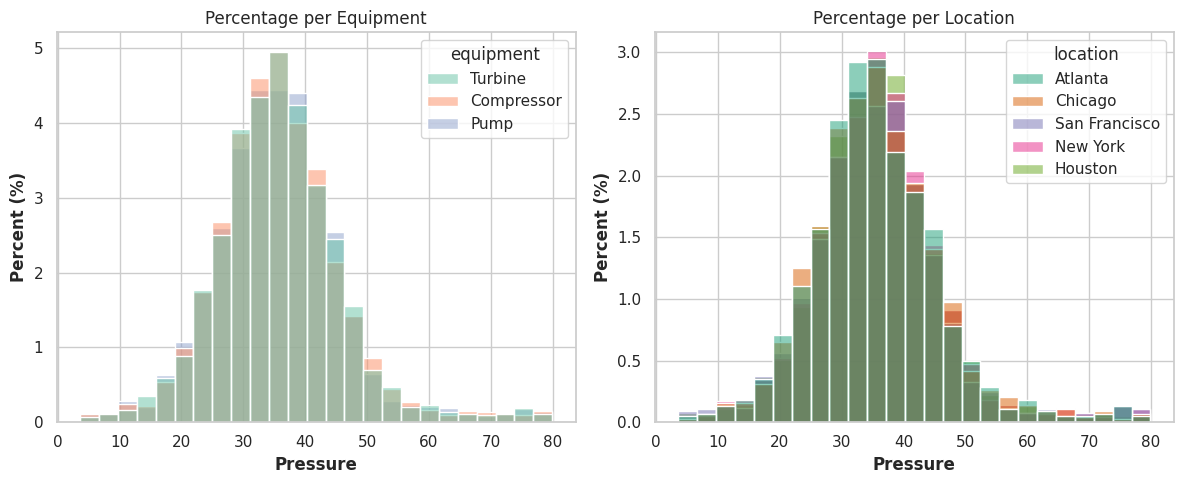

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean grid style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))

# Subplot 1: Equipment (Modern Set2 palette)
plt.subplot(1, 2, 1)
sns.histplot(
    data=df,
    x="pressure",
    hue="equipment",
    stat="percent",
    binwidth=3,
    palette="Set2",
)
plt.xlabel("Pressure", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Equipment", fontsize=12)

# Subplot 2: Location (Warm Dark2 palette)
plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x="pressure",
    hue="location",
    stat="percent",
    binwidth=3,
    palette="Dark2",
)
plt.xlabel("Pressure", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Location", fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
print(df['vibration'].describe())

count    7672.000000
mean        1.611809
std         0.728560
min        -0.428188
25%         1.170906
50%         1.533113
75%         1.924700
max         4.990537
Name: vibration, dtype: float64


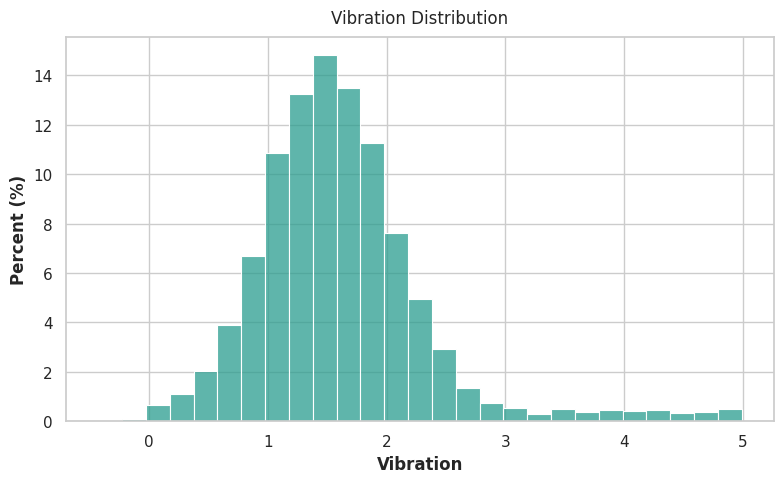

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Fast rendering using a single hex color (Emerald/Teal)
sns.histplot(
    data=df,
    x="vibration",
    stat="percent",
    binwidth=0.2,
    color="#2A9D8F",  # Emerald/Teal accent
    edgecolor="white",
    linewidth=0.8,
)

plt.xlabel("Vibration", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Vibration Distribution", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

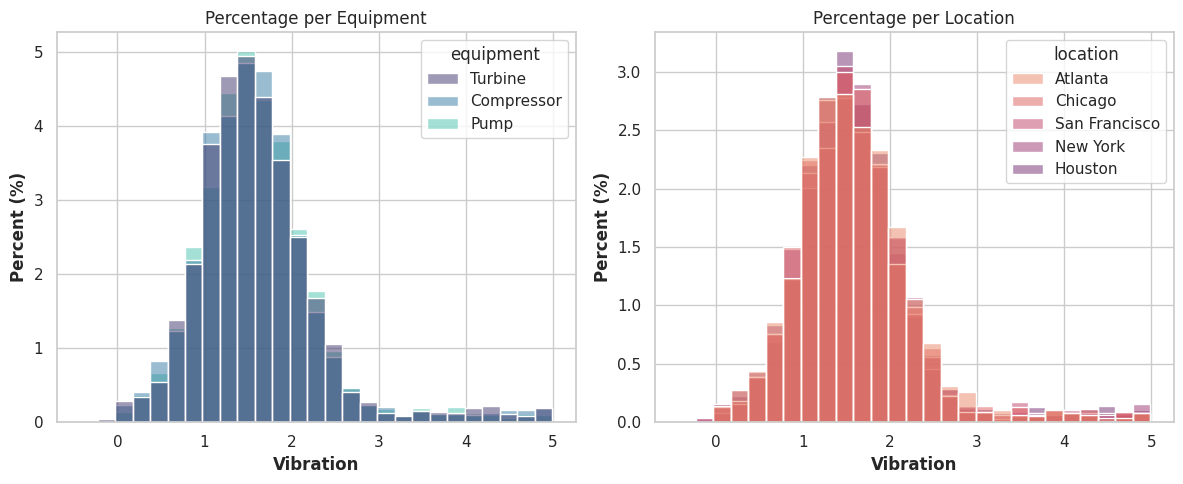

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))

# Subplot 1: Equipment (Mako palette)
plt.subplot(1, 2, 1)
sns.histplot(
    data=df,
    x="vibration",
    hue="equipment",
    stat="percent",
    binwidth=0.2,
    palette="mako",
)
plt.xlabel("Vibration", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Equipment", fontsize=12)

# Subplot 2: Location (Flare palette)
plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x="vibration",
    hue="location",
    stat="percent",
    binwidth=0.2,
    palette="flare",
)
plt.xlabel("Vibration", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Location", fontsize=12)

plt.tight_layout()
plt.show()

In [21]:
df_neg_vib = df[df['vibration'] < 0]
#print(df_neg_vib.describe())
print(df_neg_vib)

      temperature   pressure  vibration   humidity   equipment       location  \
351     68.748256  25.952101  -0.167951  50.846200     Turbine       New York   
567     65.354189  39.052701  -0.005261  48.655373     Turbine       New York   
925     75.414627  36.832759  -0.317600  28.745464        Pump        Chicago   
1685    80.240625  33.645804  -0.047145  36.778821     Turbine  San Francisco   
1893    71.376619  35.443175  -0.099632  34.219714        Pump  San Francisco   
2394    71.895816  33.898072  -0.153950  35.942537        Pump       New York   
2522    71.664522  46.135367  -0.125167  50.579747  Compressor        Houston   
4417    64.375332  33.283699  -0.164752  46.207905     Turbine  San Francisco   
6792    92.020139  27.206661  -0.167446  50.547778  Compressor       New York   
7441    64.332949  35.921919  -0.428188  43.921578     Turbine       New York   

      faulty  
351    False  
567    False  
925    False  
1685   False  
1893   False  
2394   False  
252

In [22]:
print(df['humidity'].describe())

count    7672.000000
mean       50.016574
std        11.841479
min        10.215077
25%        42.612817
50%        50.024744
75%        57.340513
max        89.984718
Name: humidity, dtype: float64


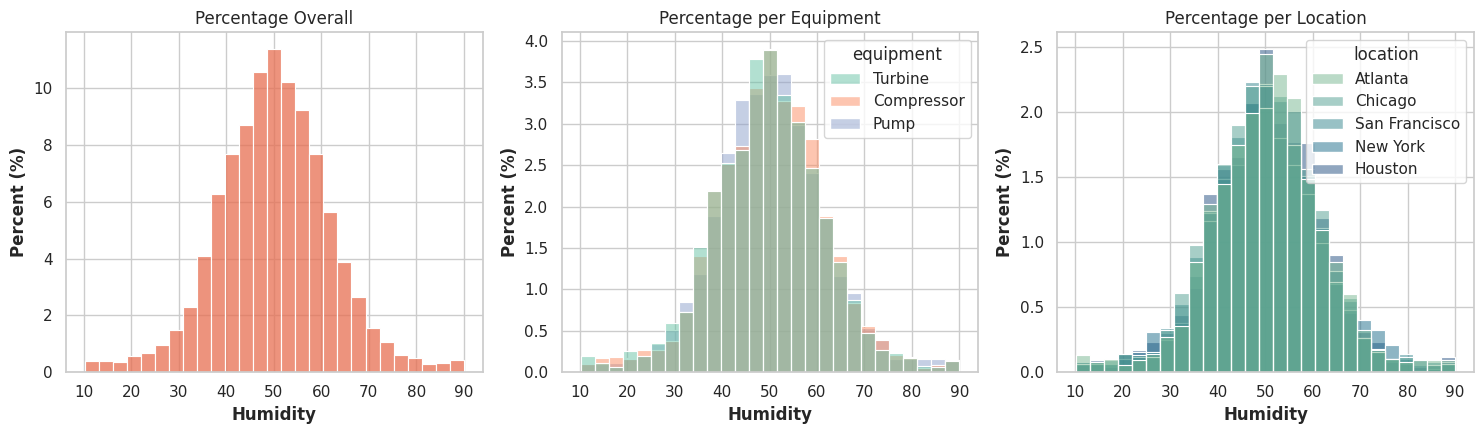

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 4.5))

# Plot 1: Overall (Single Coral Hex Color)
plt.subplot(1, 3, 1)
sns.histplot(
    data=df,
    x="humidity",
    stat="percent",
    binwidth=3,
    color="#E76F51",
    edgecolor="white",
)
plt.xlabel("Humidity", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage Overall", fontsize=12)

# Plot 2: Per Equipment (Set2 Palette)
plt.subplot(1, 3, 2)
sns.histplot(
    data=df,
    x="humidity",
    hue="equipment",
    stat="percent",
    binwidth=3,
    palette="Set2",
)
plt.xlabel("Humidity", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Equipment", fontsize=12)

# Plot 3: Per Location (Crest Palette)
plt.subplot(1, 3, 3)
sns.histplot(
    data=df,
    x="humidity",
    hue="location",
    stat="percent",
    binwidth=3,
    palette="crest",
)
plt.xlabel("Humidity", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Percentage per Location", fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
print(df['faulty'].describe())

count      7672
unique        2
top       False
freq       6905
Name: faulty, dtype: object


faulty
False    6905
True      767
Name: count, dtype: int64


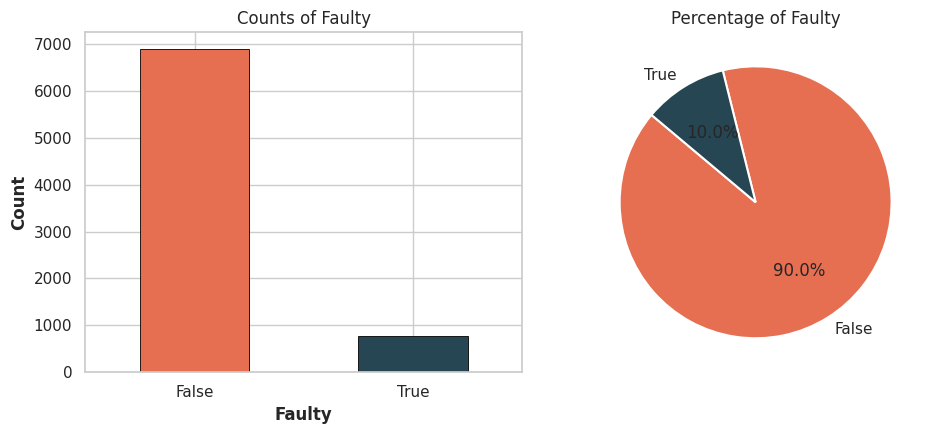

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_faulty_counts = df['faulty'].value_counts()
print(df_faulty_counts)

# Fast and clean color scheme (Coral & Slate Navy)
colors = ['#E76F51', '#264653']

plt.figure(figsize=(10, 4.5))

# Subplot 1: Bar Chart
plt.subplot(1, 2, 1)
df_faulty_counts.plot(
    kind='bar', color=colors, edgecolor='black', linewidth=0.6
)
plt.xlabel('Faulty', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Counts of Faulty', fontsize=12)
plt.xticks(rotation=0)

# Subplot 2: Pie Chart
plt.subplot(1, 2, 2)
df_faulty_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
plt.ylabel('')
plt.title('Percentage of Faulty', fontsize=12)

plt.tight_layout()
plt.show()

faulty         False  True 
location                   
Atlanta         1423    141
Chicago         1393    160
Houston         1395    153
New York        1383    143
San Francisco   1311    170


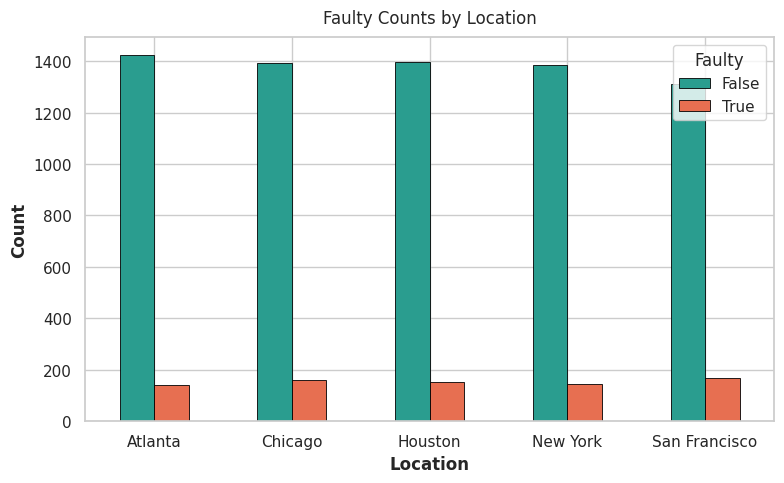

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Pivot table
df_location_faulty_counts = df.pivot_table(index=['location'], columns='faulty', aggfunc='size')
print(df_location_faulty_counts)

# Fast plot using custom hex colors (Teal & Coral)
colors = ['#2A9D8F', '#E76F51']

ax = df_location_faulty_counts.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    linewidth=0.6,
    figsize=(8, 5)
)

plt.xlabel('Location', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Faulty Counts by Location', fontsize=12, pad=10)
plt.xticks(rotation=0)
plt.legend(title='Faulty', frameon=True)

plt.tight_layout()
plt.show()

faulty      False  True 
equipment               
Compressor   2316    257
Pump         2282    252
Turbine      2307    258


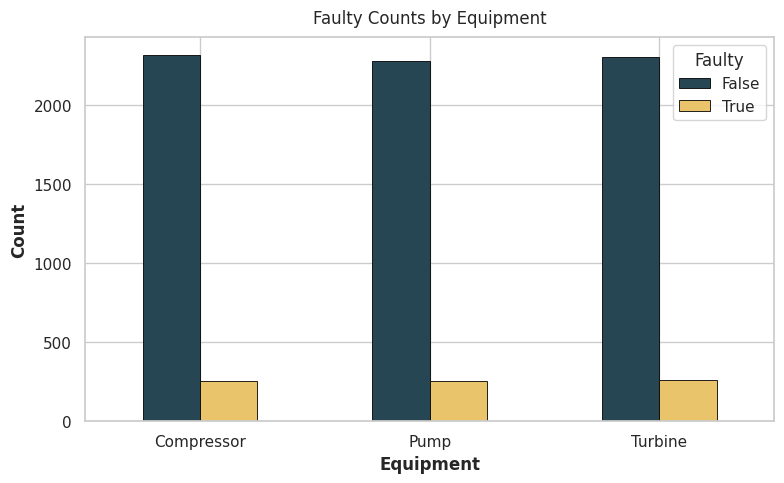

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Pivot table
df_equip_faulty_counts = df.pivot_table(index=['equipment'], columns='faulty', aggfunc='size')
print(df_equip_faulty_counts)

# Fast plot using custom hex colors (Slate Navy & Amber/Gold)
colors = ['#264653', '#E9C46A']

ax = df_equip_faulty_counts.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    linewidth=0.6,
    figsize=(8, 5)
)

plt.xlabel('Equipment', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Faulty Counts by Equipment', fontsize=12, pad=10)
plt.xticks(rotation=0)
plt.legend(title='Faulty', frameon=True)

plt.tight_layout()
plt.show()

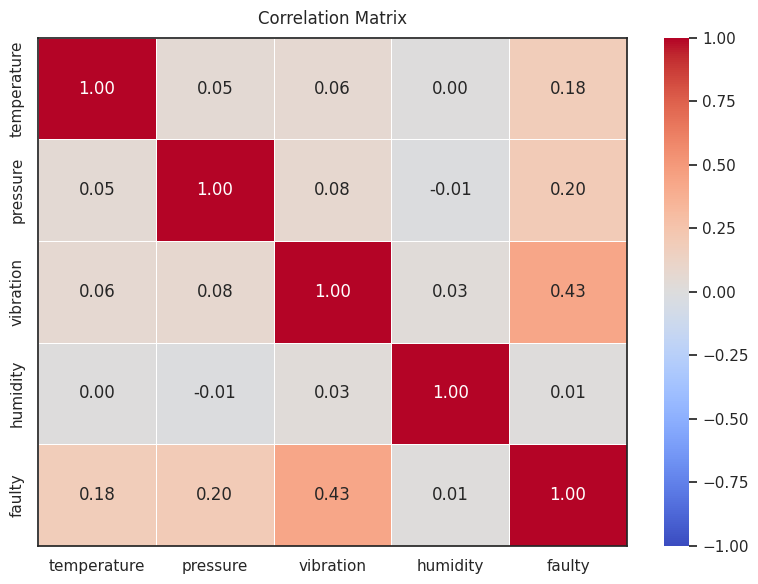

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# Drop non-numeric columns and compute correlation matrix
df_corr = df.drop(['equipment', 'location'], axis=1)
correlation = df_corr.corr()

plt.figure(figsize=(8, 6))

# Fast heatmap using 'coolwarm' colormap (Red/Blue diverging)
ax = sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    vmin=-1,
    vmax=1,
)

# Outer border frames
for _, spine in ax.spines.items():
    spine.set_visible(True)

plt.title("Correlation Matrix", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

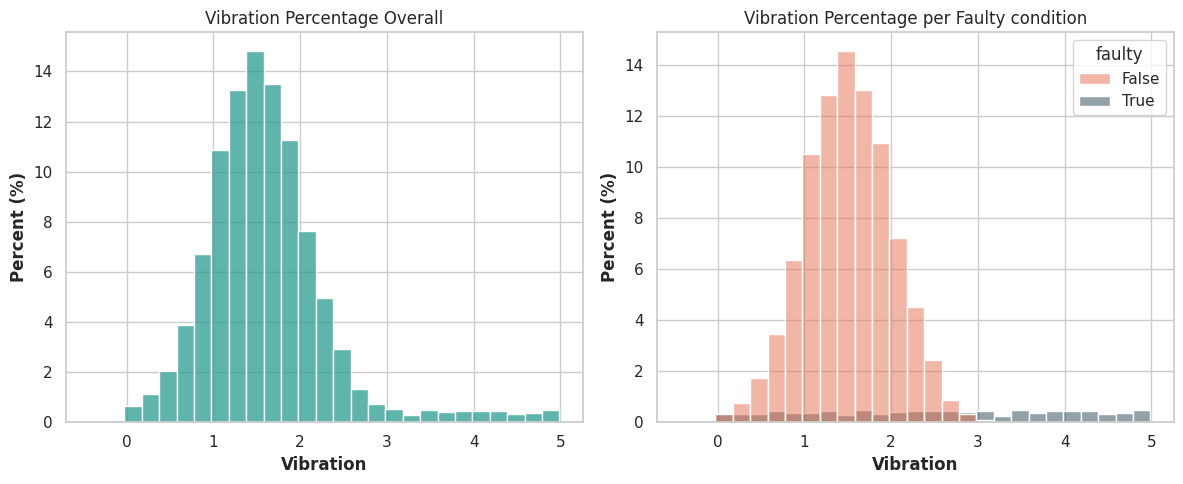

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))

# Subplot 1: Vibration Overall (Single Teal Hex Color)
plt.subplot(1, 2, 1)
sns.histplot(
    data=df,
    x="vibration",
    stat="percent",
    binwidth=0.2,
    color="#2A9D8F",
    edgecolor="white",
)
plt.xlabel("Vibration", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Vibration Percentage Overall", fontsize=12)

# Subplot 2: Per Faulty Condition (Coral & Slate Palette)
plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x="vibration",
    hue="faulty",
    stat="percent",
    binwidth=0.2,
    palette=["#E76F51", "#264653"],
)
plt.xlabel("Vibration", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Vibration Percentage per Faulty condition", fontsize=12)

plt.tight_layout()
plt.show()

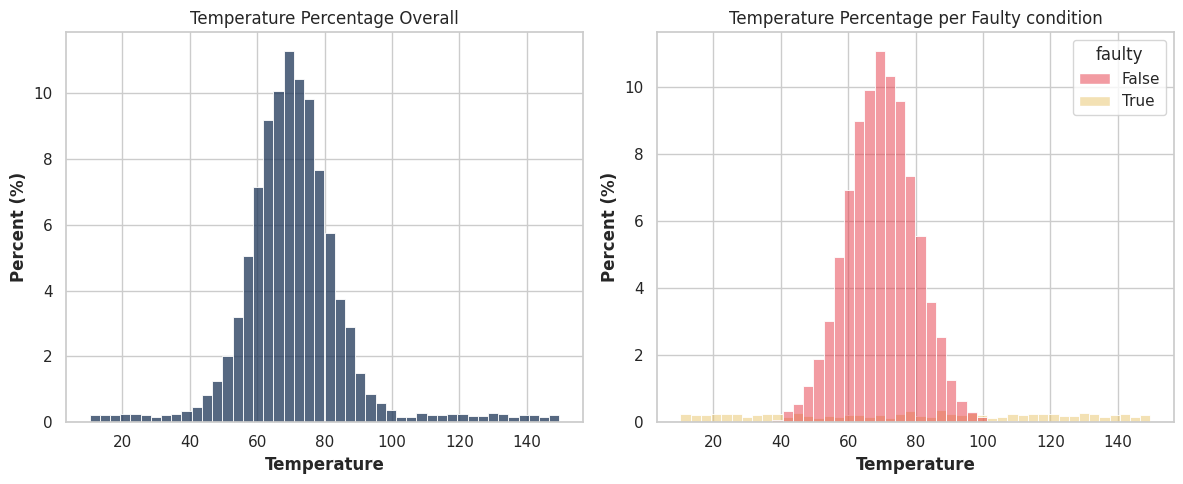

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))

# Subplot 1: Overall (Deep Navy Hex)
plt.subplot(1, 2, 1)
sns.histplot(
    data=df,
    x="temperature",
    stat="percent",
    binwidth=3,
    color="#1D3557",
    edgecolor="white",
)
plt.xlabel("Temperature", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Temperature Percentage Overall", fontsize=12)

# Subplot 2: Per Faulty Condition (Crimson & Amber Palette)
plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x="temperature",
    hue="faulty",
    stat="percent",
    binwidth=3,
    palette=["#E63946", "#E9C46A"],
)
plt.xlabel("Temperature", fontweight="bold")
plt.ylabel("Percent (%)", fontweight="bold")
plt.title("Temperature Percentage per Faulty condition", fontsize=12)

plt.tight_layout()
plt.show()

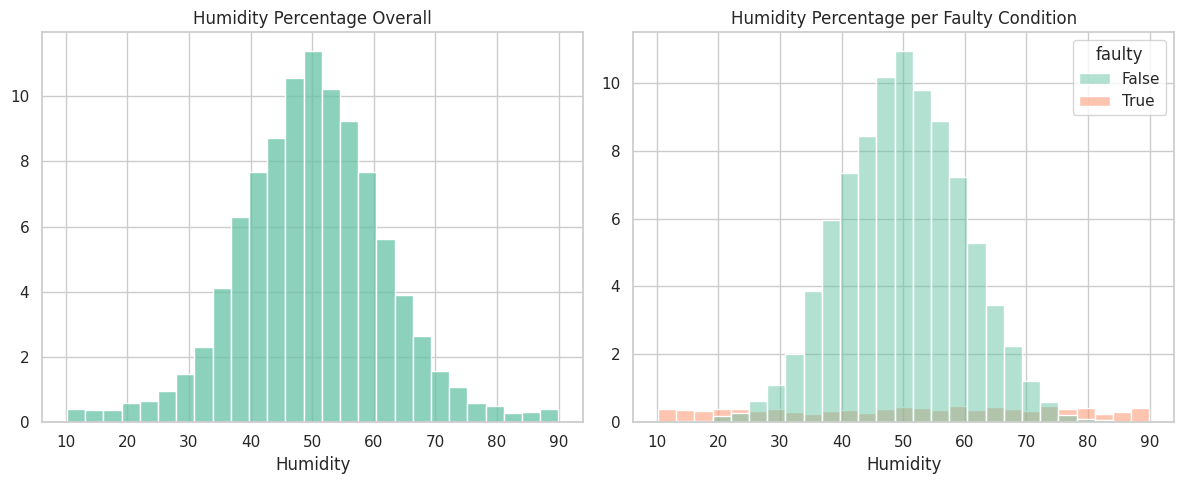

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean theme and modern color scheme
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Overall
sns.histplot(
    data=df,
    x="humidity",
    stat="percent",
    binwidth=3,
    color=palette[0],
    ax=axes[0],
)
axes[0].set(xlabel="Humidity", ylabel="", title="Humidity Percentage Overall")

# Plot 2: Per Faulty Condition
sns.histplot(
    data=df,
    x="humidity",
    hue="faulty",
    stat="percent",
    binwidth=3,
    palette="Set2",
    ax=axes[2 - 1],
)
axes[1].set(
    xlabel="Humidity", ylabel="", title="Humidity Percentage per Faulty Condition"
)

plt.tight_layout()
plt.show()

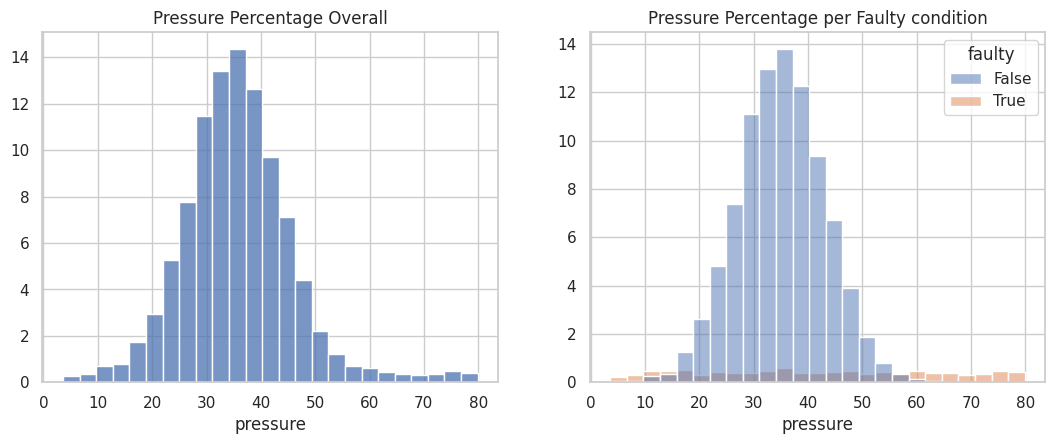

In [32]:
plt.figure(figsize=(20, 10))

plt.subplot(2,3,1)
sns.histplot(data=df, x='pressure', stat="percent", binwidth=3)
plt.xlabel('pressure')
plt.ylabel('')
plt.title('Pressure Percentage Overall')

plt.subplot(2,3,2)
sns.histplot(data=df, x='pressure', hue='faulty', stat="percent", binwidth=3)
plt.xlabel('pressure')
plt.ylabel('')
plt.title('Pressure Percentage per Faulty condition')

plt.show()

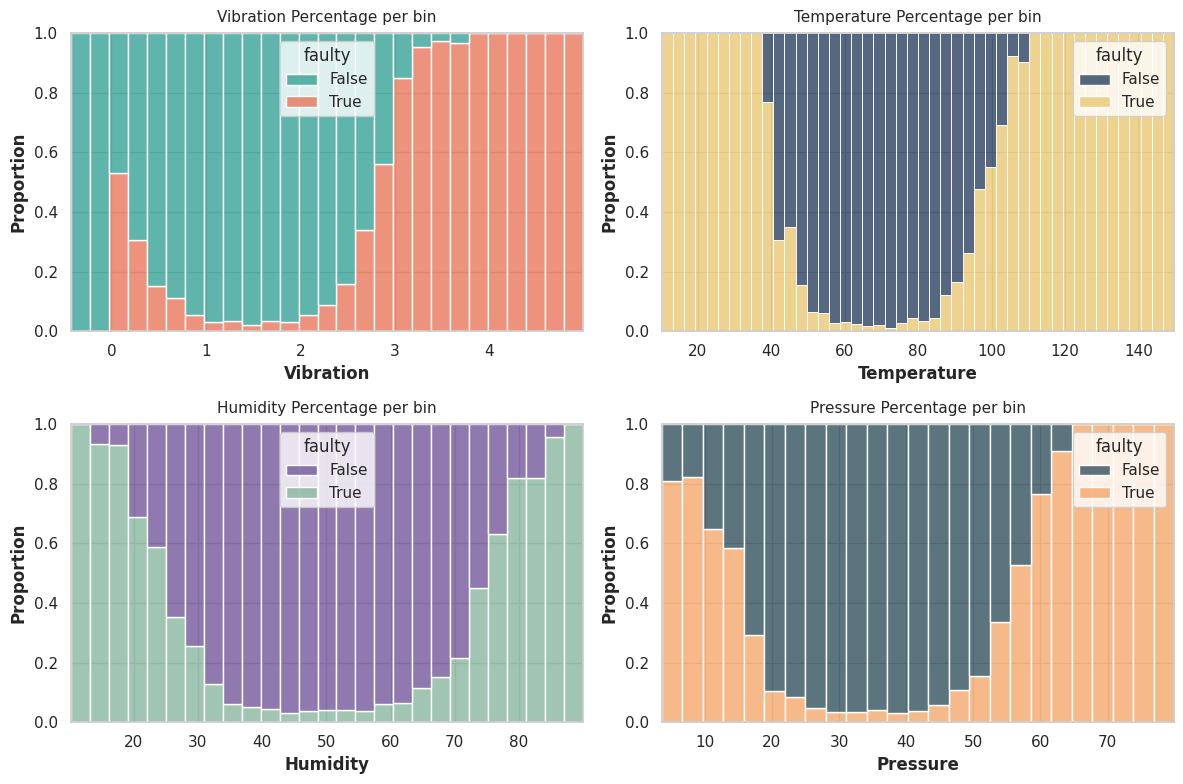

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Define 100% stacked histogram configurations: (variable, binwidth, palette)
metrics = [
    ('vibration', 0.2, ['#2A9D8F', '#E76F51']),    # Emerald & Coral
    ('temperature', 3, ['#1D3557', '#E9C46A']),    # Navy & Gold
    ('humidity', 3, ['#6A4C93', '#81B29A']),       # Purple & Mint
    ('pressure', 3, ['#264653', '#F4A261']),       # Slate & Orange
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (col, bw, pal) in zip(axes.flat, metrics):
    sns.histplot(
        data=df,
        x=col,
        hue='faulty',
        stat='percent',
        multiple='fill',
        binwidth=bw,
        palette=pal,
        ax=ax,
    )
    ax.set_title(f'{col.capitalize()} Percentage per bin', fontsize=11, pad=8)
    ax.set_xlabel(col.capitalize(), fontweight='bold')
    ax.set_ylabel('Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# Copy df
df_train = df.copy()
df_train.head(5)

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,False
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,False
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,False
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,False
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,False


In [35]:
def transform_negative_to_zero(x):
  if x < 0:
    return 0
  else:
    return x

df_train['vibration'] = df_train['vibration'].apply(lambda x : transform_negative_to_zero(x))
print(df_train[df_train['vibration'] < 0])

Empty DataFrame
Columns: [temperature, pressure, vibration, humidity, equipment, location, faulty]
Index: []


In [36]:
from sklearn.preprocessing import MinMaxScaler
operational_data_columns = ['vibration', 'temperature', 'pressure', 'humidity']
standard_scaler = MinMaxScaler()

df_train[operational_data_columns] = standard_scaler.fit_transform(df_train[operational_data_columns])
df_train[operational_data_columns].head(5)

,vibration,temperature,pressure,humidity
0,0.121533,0.343641,0.280705,0.444779
1,0.468506,0.469594,0.253494,0.396797
2,0.278366,0.438164,0.310174,0.611001
3,0.354809,0.440017,0.375289,0.380471
4,0.069211,0.403364,0.545147,0.414177


In [37]:
from sklearn.preprocessing import OneHotEncoder
meta_data_columns = ['equipment', 'location']
one_hot_encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = one_hot_encoder.fit_transform(df_train[meta_data_columns])
df_one_hot = pd.DataFrame(one_hot_encoded, columns=one_hot_encoder.get_feature_names_out(meta_data_columns))

df_train_with_meta_data = pd.concat([df_train, df_one_hot], axis=1).drop(['equipment', 'location'], axis=1)
print(df_train_with_meta_data.head(5))

   temperature  pressure  vibration  humidity  faulty  equipment_Compressor  \
0     0.343641  0.280705   0.121533  0.444779   False                   0.0   
1     0.469594  0.253494   0.468506  0.396797   False                   1.0   
2     0.438164  0.310174   0.278366  0.611001   False                   0.0   
3     0.440017  0.375289   0.354809  0.380471   False                   0.0   
4     0.403364  0.545147   0.069211  0.414177   False                   0.0   

   equipment_Pump  equipment_Turbine  location_Atlanta  location_Chicago  \
0             0.0                1.0               1.0               0.0   
1             0.0                0.0               0.0               1.0   
2             0.0                1.0               0.0               0.0   
3             1.0                0.0               1.0               0.0   
4             1.0                0.0               0.0               0.0   

   location_Houston  location_New York  location_San Francisco  
0  

In [38]:
df_train = df_train.drop(['equipment', 'location'], axis=1)
print(df_train.head(5))

   temperature  pressure  vibration  humidity  faulty
0     0.343641  0.280705   0.121533  0.444779   False
1     0.469594  0.253494   0.468506  0.396797   False
2     0.438164  0.310174   0.278366  0.611001   False
3     0.440017  0.375289   0.354809  0.380471   False
4     0.403364  0.545147   0.069211  0.414177   False


In [39]:
from sklearn.model_selection import train_test_split

X = df_train.drop(['faulty'], axis=1)
y = df_train['faulty']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


X_with_meta_data = df_train_with_meta_data.drop(['faulty'], axis=1)
y_with_meta_data = df_train_with_meta_data['faulty']
X_train_md, X_test_md, y_train_md, y_test_md = train_test_split(X_with_meta_data, y_with_meta_data, test_size = 0.2, random_state = 42)


print(f" Without Meta Data shapes: {X_train.shape}, {X_test.shape}, {y_train.shape}, {y_test.shape}")
print(f" With Meta Data shapes: {X_train_md.shape}, {X_test_md.shape}, {y_train_md.shape}, {y_test_md.shape}")

 Without Meta Data shapes: (6137, 4), (1535, 4), (6137,), (1535,)
 With Meta Data shapes: (6137, 12), (1535, 12), (6137,), (1535,)


In [40]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

def metrics(real, pred):
    class_report = classification_report(real, pred)
    accuracy = accuracy_score(real, pred)
    print(f"Classification Report :\n\n{class_report}")
    print(f"Accuracy : {accuracy:.4f}")

def plot_confusion_matrix(real, pred):
  cm = confusion_matrix(real, pred)
  print(f"Confusion Matrix:")
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()
  plt.show()

def plot_roc_curve(real, pred):
  # Compute fpr, tpr, thresholds and roc auc
  fpr, tpr, thresholds = roc_curve(real, pred)
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  print(f"ROC Curve:")
  plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc)
  plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.xlabel('False Positive Rate or (1 - Specifity)')
  plt.ylabel('True Positive Rate or (Sensitivity)')
  plt.title('ROC Curve')
  plt.legend(loc="lower right")

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [42]:
grid_search_rf = GridSearchCV(RandomForestClassifier(),
                              param_grid = {'max_depth': [5, 10, None],
                                            'max_features': [10, 20, 30, 40, None]})
grid_search_rf.fit(X_train, y_train)
print(grid_search_rf.best_estimator_)

RandomForestClassifier(max_features=30)


Classification Report :

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      1377
        True       0.94      0.85      0.90       158

    accuracy                           0.98      1535
   macro avg       0.96      0.92      0.94      1535
weighted avg       0.98      0.98      0.98      1535

Accuracy : 0.9798
Confusion Matrix:


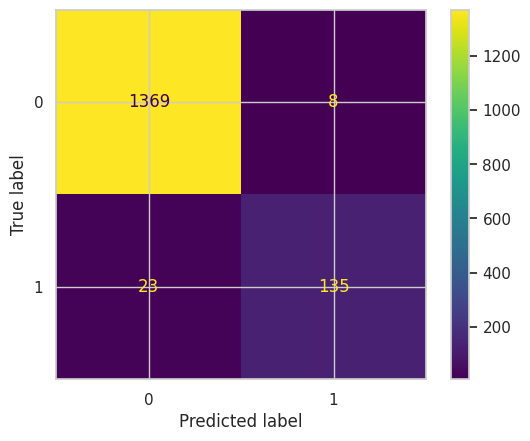

ROC Curve:


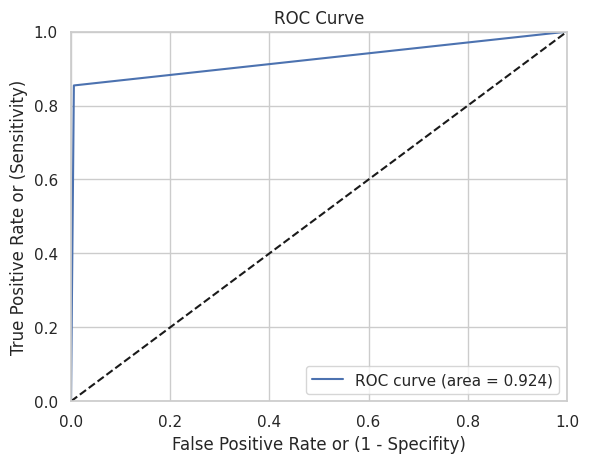

In [43]:
model_rf = RandomForestClassifier(max_depth=10, max_features=20)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

metrics(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred)

In [44]:
grid_search_rf_md = GridSearchCV(RandomForestClassifier(),
                              param_grid = {'max_depth': [5, 10, None],
                                            'max_features': [10, 20, 30, 40, None]})
grid_search_rf_md.fit(X_train_md, y_train_md)
print(grid_search_rf_md.best_estimator_)

RandomForestClassifier(max_features=20)


Classification Report :

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      1377
        True       0.94      0.85      0.89       158

    accuracy                           0.98      1535
   macro avg       0.96      0.92      0.94      1535
weighted avg       0.98      0.98      0.98      1535

Accuracy : 0.9792
Confusion Matrix:


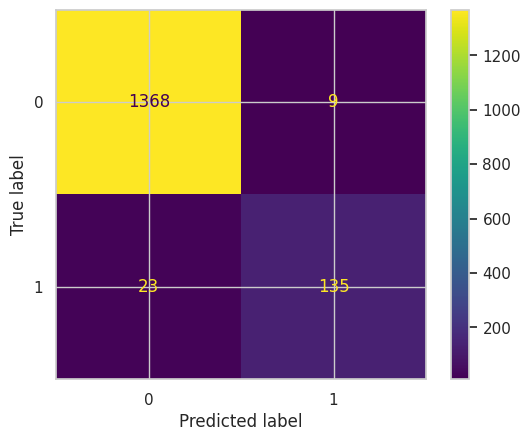

ROC Curve:


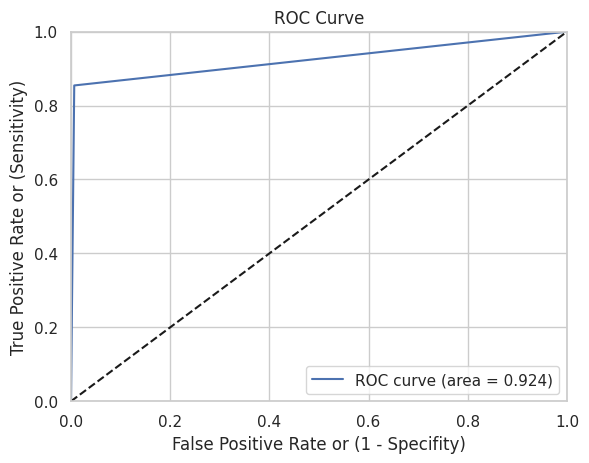

In [45]:
model_rf_md = RandomForestClassifier(max_depth=10, max_features=10)
model_rf.fit(X_train_md, y_train_md)
y_pred_md = model_rf.predict(X_test_md)

metrics(y_test_md, y_pred_md)
plot_confusion_matrix(y_test_md, y_pred_md)
plot_roc_curve(y_test_md, y_pred_md)

In [46]:
from sklearn.linear_model import LogisticRegression


In [47]:
grid_search_lr = GridSearchCV(LogisticRegression(),
                              param_grid = {'solver': ['liblinear'],
                                            'penalty':['l2', None],
                                            'C' : np.logspace(-4,4,20),
                                            'max_iter': [100, 200, 300, 400, 500]})
grid_search_lr.fit(X_train, y_train)
print(grid_search_lr.best_estimator_)

LogisticRegression(C=np.float64(29.763514416313132), solver='liblinear')


Classification Report :

              precision    recall  f1-score   support

       False       0.93      1.00      0.96      1377
        True       0.98      0.37      0.54       158

    accuracy                           0.93      1535
   macro avg       0.96      0.69      0.75      1535
weighted avg       0.94      0.93      0.92      1535

Accuracy : 0.9349
Confusion Matrix:


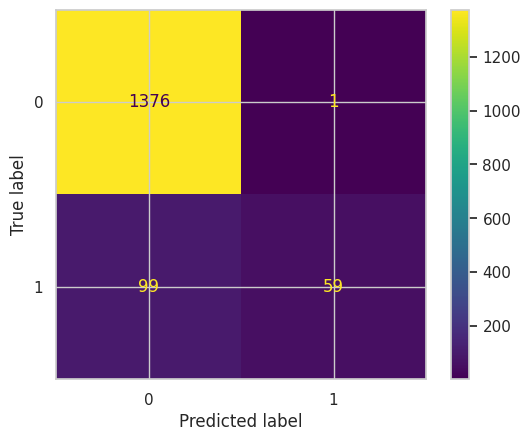

ROC Curve:


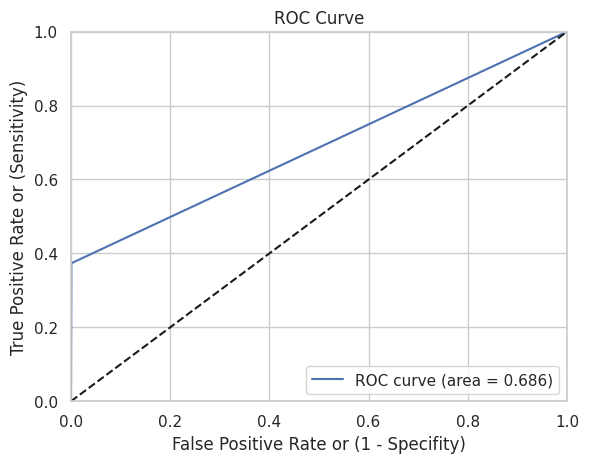

In [48]:
model_lr = LogisticRegression(C=29.763514416313132, solver='liblinear')
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

metrics(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred)

Classification Report :

              precision    recall  f1-score   support

       False       0.99      0.99      0.99      1377
        True       0.95      0.89      0.92       158

    accuracy                           0.98      1535
   macro avg       0.97      0.94      0.95      1535
weighted avg       0.98      0.98      0.98      1535

Accuracy : 0.9837
Confusion Matrix:


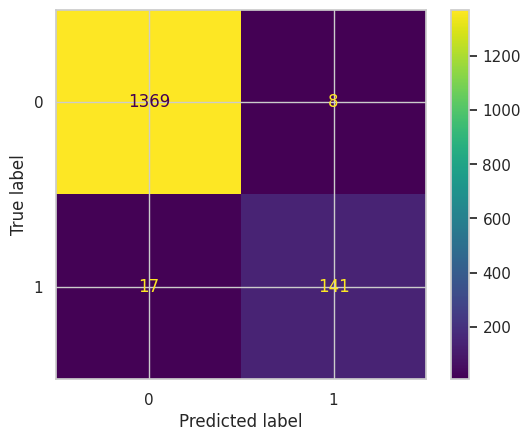

ROC Curve:


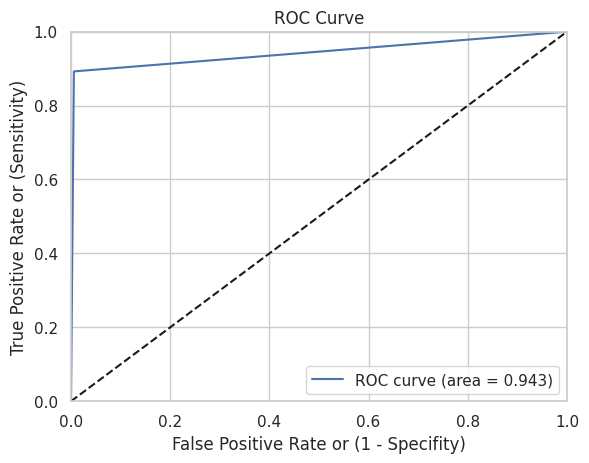

In [49]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(objective="binary:logistic", random_state=42)
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

metrics(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred)

[LightGBM] [Info] Number of positive: 609, number of negative: 5528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 6137, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099234 -> initscore=-2.205763
[LightGBM] [Info] Start training from score -2.205763
Classification Report :

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      1377
        True       0.94      0.87      0.90       158

    accuracy                           0.98      1535
   macro avg       0.96      0.93      0.95      1535
weighted avg       0.98      0.98      0.98      1535

Accuracy : 0.9811
Confusion Matrix:


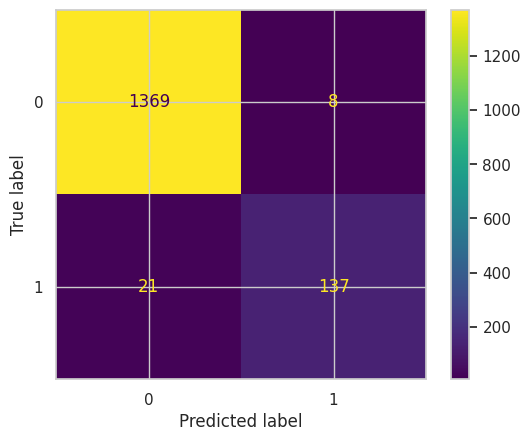

ROC Curve:


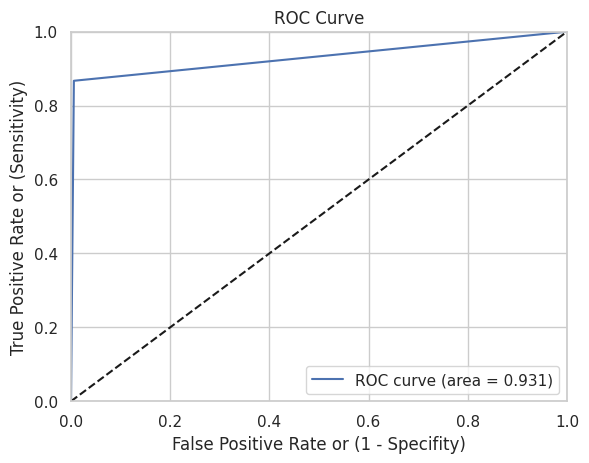

In [50]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(metric='auc')
model_lgbm.fit(X_train, y_train)

y_pred = model_lgbm.predict(X_test)

metrics(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred)